# Qwen2-VL Chart VQA — QLoRA Fine-tuning (T4)
**Dataset:** `Zenng2812/vqa-vietnamese-charts`  
**Model:** `Qwen/Qwen2-VL-2B-Instruct`  
**Method:** 4-bit QLoRA (LoRA r=16, α=32)

---
## Mục lục
1. Cài đặt thư viện
2. Cấu hình & Google Drive
3. Load dataset & EDA
4. Load model & LoRA
5. Data Collator
6. Training
7. Inference
8. Evaluation (EM, Soft-Acc, BLEU, ROUGE-L, BERTScore)
9. Lưu kết quả

## 1. Cài đặt thư viện

In [2]:
!pip install -q -U \
    transformers accelerate peft bitsandbytes \
    qwen-vl-utils datasets \
    evaluate rouge-score bert-score nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 21.8 MB/s eta 0:00:00


## 2. Cấu hình & Google Drive

In [3]:
import os, re, json, math, random
import torch
import numpy as np
import pandas as pd
from datetime import datetime
from PIL import Image
from tqdm import tqdm

from transformers import (
    AutoProcessor, Qwen2VLForConditionalGeneration,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from qwen_vl_utils import process_vision_info

# ── Paths ──────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

DRIVE_DIR        = "/content/drive/MyDrive/B2_Qwen2VL_VQA_Charts"
CHECKPOINT_DIR   = f"{DRIVE_DIR}/checkpoints"
LOG_DIR          = f"{DRIVE_DIR}/logs"
FINAL_MODEL_DIR  = f"{DRIVE_DIR}/final_model"
RESULT_DIR       = f"{DRIVE_DIR}/results"

for d in [CHECKPOINT_DIR, LOG_DIR, FINAL_MODEL_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Constants ──────────────────────────────────────────────
DATASET_ID   = "Zenng2812/vqa-vietnamese-charts"
MODEL_ID     = "Qwen/Qwen2-VL-2B-Instruct"
IMAGE_COL    = "image"
QUESTION_COL = "question"
ANSWER_COL   = "answer"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM   : {vram:.1f} GB")

Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
VRAM   : 14.6 GB


## 3. Load dataset & EDA

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/23.2M [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3344 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/416 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/424 [00:00<?, ? examples/s]

Train : 3,344 samples
Val   : 416 samples
Test  : 424 samples

Chart type distribution:
chart_type
bar     848
area    844
pie     828
line    824

Answer length (words):
count    3344.00
mean        7.01
std         2.43
min         1.00
25%         5.00
50%         7.00
75%         8.00
max        19.00


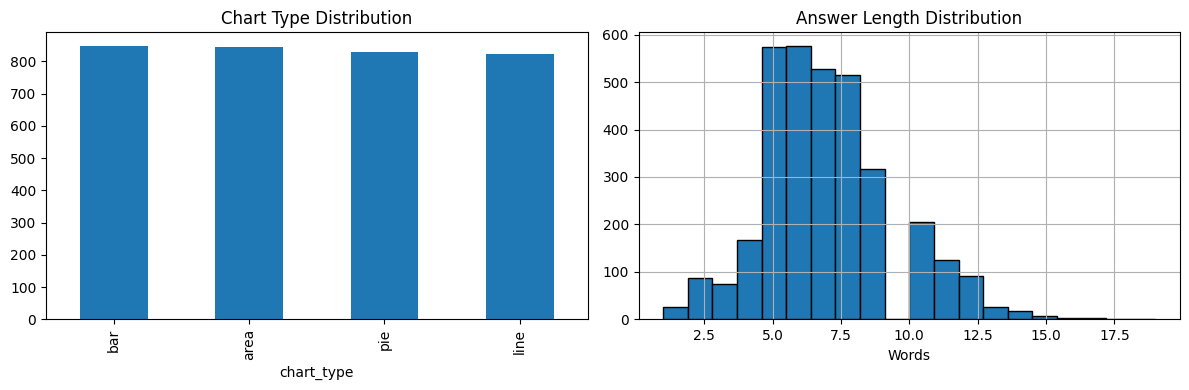

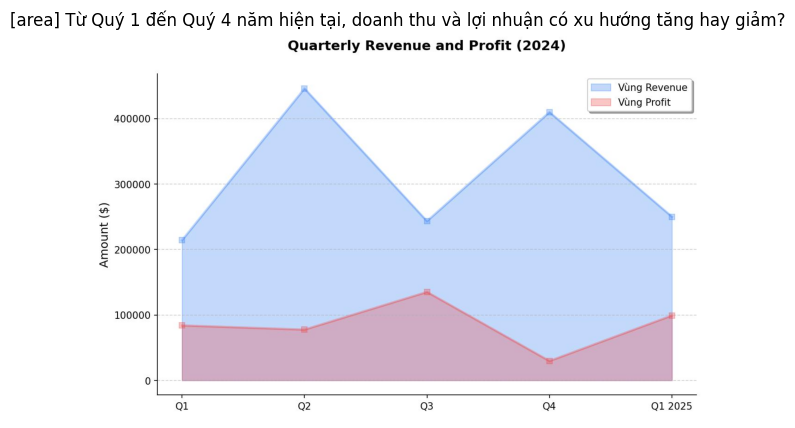

Answer: Tăng nhẹ rồi giảm sau Quý 3


In [4]:
from datasets import load_dataset
import matplotlib.pyplot as plt

ds       = load_dataset(DATASET_ID)
train_ds = ds["train"]
val_ds   = ds["validation"]
test_ds  = ds["test"]

print(f"Train : {len(train_ds):,} samples")
print(f"Val   : {len(val_ds):,} samples")
print(f"Test  : {len(test_ds):,} samples")

# Chart type distribution
train_meta = train_ds.remove_columns([IMAGE_COL]).to_pandas()
train_meta["answer_len"]   = train_meta[ANSWER_COL].astype(str).str.split().str.len()
train_meta["question_len"] = train_meta[QUESTION_COL].astype(str).str.split().str.len()

print("\nChart type distribution:")
print(train_meta["chart_type"].value_counts().to_string())

print("\nAnswer length (words):")
print(train_meta["answer_len"].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_meta["chart_type"].value_counts().plot(kind="bar", ax=axes[0], title="Chart Type Distribution")
train_meta["answer_len"].hist(bins=20, ax=axes[1], edgecolor="black")
axes[1].set_title("Answer Length Distribution")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

# Show one sample
sample = train_ds[0]
plt.figure(figsize=(8, 5))
plt.imshow(sample[IMAGE_COL])
plt.axis("off")
plt.title(f"[{sample['chart_type']}] {sample[QUESTION_COL]}")
plt.show()
print("Answer:", sample[ANSWER_COL])

## 4. Load model & LoRA

In [5]:
# ── Processor ─────────────────────────────────────────────
# T4: 16 GB VRAM — giảm max_pixels để tránh OOM
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    min_pixels=32  * 28 * 28,
    max_pixels=128 * 28 * 28,
)

# ── 4-bit quantization ────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,   # T4 không hỗ trợ bfloat16
    bnb_4bit_use_double_quant=True,
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

# ── LoRA ──────────────────────────────────────────────────
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290


## 5. Prompt & Data Collator

In [6]:
SYSTEM_PROMPT = (
    "Bạn là chuyên gia phân tích biểu đồ. "
    "Quan sát biểu đồ và trả lời câu hỏi về xu hướng, so sánh, hoặc nhận xét tổng quan. "
    "Trả lời bằng tiếng Việt, ngắn gọn, không cần trích xuất số liệu cụ thể."
)

def build_messages(image, question, answer=None):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": str(question)},
        ]},
    ]
    if answer is not None:
        messages.append({"role": "assistant", "content": str(answer)})
    return messages


class QwenVQACollator:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, examples):
        full_texts, prompt_texts, images = [], [], []

        for ex in examples:
            img      = ex[IMAGE_COL].convert("RGB")
            question = str(ex[QUESTION_COL]).strip()
            answer   = str(ex[ANSWER_COL]).strip()

            full_texts.append(self.processor.apply_chat_template(
                build_messages(img, question, answer),
                tokenize=False, add_generation_prompt=False
            ))
            prompt_texts.append(self.processor.apply_chat_template(
                build_messages(img, question),
                tokenize=False, add_generation_prompt=True
            ))
            images.append(img)

        batch = self.processor(
            text=full_texts, images=images,
            padding=True, return_tensors="pt"
        )
        labels = batch["input_ids"].clone()

        pad_id = self.processor.tokenizer.pad_token_id
        if pad_id is not None:
            labels[labels == pad_id] = -100

        prompt_batch = self.processor(
            text=prompt_texts, images=images,
            padding=True, return_tensors="pt"
        )
        for i in range(labels.shape[0]):
            prompt_len = prompt_batch["attention_mask"][i].sum().item()
            labels[i, :prompt_len] = -100

        batch["labels"] = labels
        return batch


collator = QwenVQACollator(processor)

# Quick sanity check
sb = collator([train_ds[0]])
n_answer_tokens = (sb["labels"] != -100).sum().item()
print(f"input_ids : {tuple(sb['input_ids'].shape)}")
print(f"labels    : {tuple(sb['labels'].shape)}")
print(f"Answer tokens for loss: {n_answer_tokens}")
if n_answer_tokens == 0:
    raise ValueError("Labels bị mask hết — kiểm tra lại collator!")

input_ids : (1, 218)
labels    : (1, 218)
Answer tokens for loss: 11


## 6. Training

In [7]:
# ── Callback: ghi log gọn ─────────────────────────────────
class TrainingLogCallback(TrainerCallback):
    def __init__(self, log_dir, print_every=10):
        self.log_dir     = log_dir
        self.records     = []
        self.print_every = print_every
        self.csv_path    = os.path.join(log_dir, "training_log.csv")
        self.json_path   = os.path.join(log_dir, "training_log.json")
        os.makedirs(log_dir, exist_ok=True)

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        record = {
            "time"          : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "step"          : state.global_step,
            "epoch"         : logs.get("epoch"),
            "loss"          : logs.get("loss"),
            "eval_loss"     : logs.get("eval_loss"),
            "learning_rate" : logs.get("learning_rate"),
            "grad_norm"     : logs.get("grad_norm"),
        }
        if any(record[k] is not None for k in ["loss", "eval_loss", "learning_rate"]):
            self.records.append(record)
            pd.DataFrame(self.records).to_csv(self.csv_path, index=False, encoding="utf-8-sig")
            with open(self.json_path, "w", encoding="utf-8") as f:
                json.dump(self.records, f, ensure_ascii=False, indent=2)

        if record["loss"] is not None and state.global_step % self.print_every == 0:
            print(f"[TRAIN] step={record['step']} | epoch={record['epoch']:.4f} "
                  f"| loss={record['loss']:.4f} | lr={record['learning_rate']:.2e}")
        if record["eval_loss"] is not None:
            print(f"[EVAL]  step={record['step']} | epoch={record['epoch']:.4f} "
                  f"| eval_loss={record['eval_loss']:.4f}")


# ── Helper: tìm checkpoint mới nhất ──────────────────────
def get_latest_checkpoint(ckpt_dir):
    if not os.path.exists(ckpt_dir):
        return None
    ckpts = []
    for name in os.listdir(ckpt_dir):
        m = re.search(r"checkpoint-(\d+)", name)
        if m and os.path.isdir(os.path.join(ckpt_dir, name)):
            ckpts.append((int(m.group(1)), os.path.join(ckpt_dir, name)))
    return sorted(ckpts)[-1][1] if ckpts else None


# ── TrainingArguments ─────────────────────────────────────
training_args = TrainingArguments(
    output_dir                = CHECKPOINT_DIR,
    num_train_epochs           = 2,
    per_device_train_batch_size= 1,
    per_device_eval_batch_size = 1,
    gradient_accumulation_steps= 8,
    learning_rate              = 1e-5,
    warmup_steps               = 30,
    lr_scheduler_type          = "cosine",
    logging_strategy           = "steps",
    logging_steps              = 10,
    logging_first_step         = True,
    logging_dir                = LOG_DIR,
    eval_strategy              = "steps",
    eval_steps                 = 200,
    save_strategy              = "steps",
    save_steps                 = 200,
    save_total_limit           = 3,
    load_best_model_at_end     = True,
    metric_for_best_model      = "eval_loss",
    greater_is_better          = False,
    fp16                       = False,
    bf16                       = False,
    gradient_checkpointing     = True,
    max_grad_norm              = 0.3,
    remove_unused_columns      = False,
    optim                      = "paged_adamw_8bit",
    report_to                  = "none",
    seed                       = 42,
    data_seed                  = 42,
)

steps_per_epoch = math.ceil(len(train_ds) / (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps))
total_steps     = int(steps_per_epoch * training_args.num_train_epochs)
print(f"Steps/epoch : {steps_per_epoch}")
print(f"Total steps : {total_steps}")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Steps/epoch : 418
Total steps : 836


In [8]:
log_callback = TrainingLogCallback(log_dir=LOG_DIR, print_every=10)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    data_collator = collator,
    callbacks     = [log_callback],
)

latest_ckpt = get_latest_checkpoint(CHECKPOINT_DIR)
print("Resume from:", latest_ckpt or "scratch")

train_result = trainer.train(resume_from_checkpoint=latest_ckpt)
print(train_result)

# Save final model
trainer.save_model(FINAL_MODEL_DIR)
processor.save_pretrained(FINAL_MODEL_DIR)
print(f"\nModel saved to: {FINAL_MODEL_DIR}")
print(f"Best eval loss: {trainer.state.best_metric}")
print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")

Resume from: /content/drive/MyDrive/B2_Qwen2VL_VQA_Charts/checkpoints/checkpoint-836


Step,Training Loss,Validation Loss


TrainOutput(global_step=836, training_loss=0.0, metrics={'train_runtime': 0.0221, 'train_samples_per_second': 302905.852, 'train_steps_per_second': 37863.232, 'total_flos': 2.8949231422347264e+16, 'train_loss': 0.0, 'epoch': 2.0})


KeyboardInterrupt: 

## 7. Inference

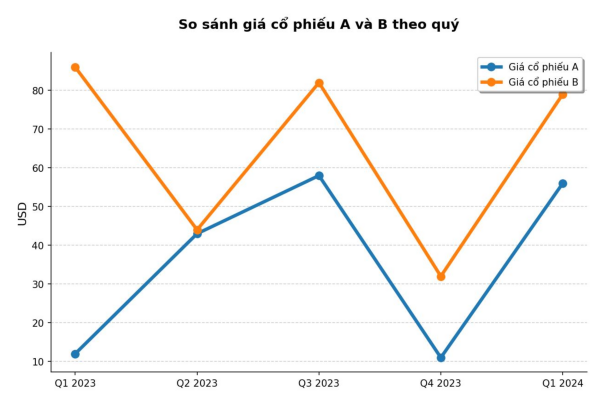

[line] idx=327
Question : Nửa đầu và nửa cuối năm 2023 có sự khác biệt gì về giá cổ phiếu B?
Gold     : B giảm mạnh giữa năm, sau đó tăng
Pred     : Nửa đầu năm 2023 có giá thấp hơn nửa cuối



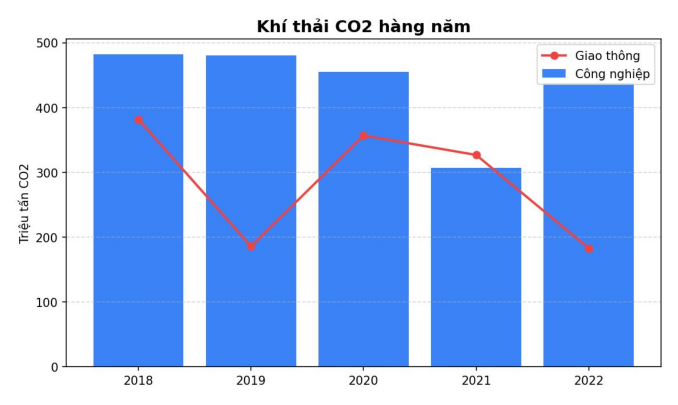

[bar] idx=57
Question : So sánh nửa đầu (2018-2020) và nửa cuối (2021-2022) về thay đổi trung bình của Công nghiệp?
Gold     : Nửa cuối tăng mạnh hơn
Pred     : Nửa đầu công nghiệp giảm mạnh, nửa cuối tăng nhẹ



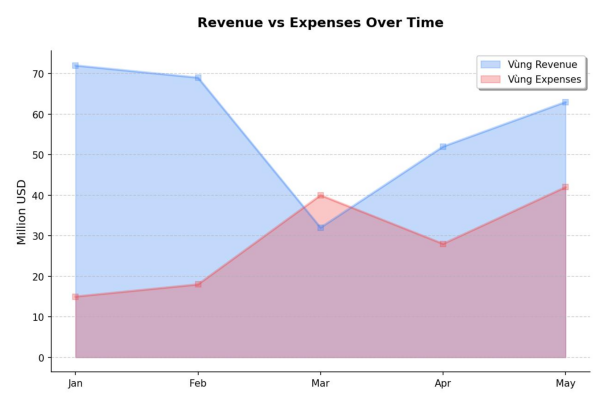

[area] idx=12
Question : Tháng nào chi phí đạt mức thấp nhất và tháng nào doanh thu đạt mức cao nhất?
Gold     : Chi phí thấp nhất tháng Tháng 1, doanh thu cao nhất tháng Tháng 5
Pred     : Tháng 3 có chi phí thấp nhất và tháng 5 có doanh thu cao nhất



In [9]:
def predict(image, question, max_new_tokens=64):
    image = image.convert("RGB")
    text  = processor.apply_chat_template(
        build_messages(image, question),
        tokenize=False, add_generation_prompt=True
    )
    inputs = processor(
        text=[text], images=[image],
        padding=True, return_tensors="pt"
    ).to(model.device)

    model.eval()
    with torch.no_grad():
        generated = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, generated)]
    return processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()


def show_prediction(dataset, idx=None):
    idx    = idx if idx is not None else random.randint(0, len(dataset) - 1)
    sample = dataset[idx]
    pred   = predict(sample[IMAGE_COL], sample[QUESTION_COL])

    plt.figure(figsize=(9, 5))
    plt.imshow(sample[IMAGE_COL])
    plt.axis("off")
    plt.show()
    print(f"[{sample['chart_type']}] idx={idx}")
    print(f"Question : {sample[QUESTION_COL]}")
    print(f"Gold     : {sample[ANSWER_COL]}")
    print(f"Pred     : {pred}")

# Test vài mẫu
for _ in range(3):
    show_prediction(test_ds)
    print()

## 8. Evaluation

In [10]:
import evaluate as hf_evaluate
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

rouge_metric    = hf_evaluate.load("rouge")
bertscore_metric = hf_evaluate.load("bertscore")

# ── Helpers ───────────────────────────────────────────────
_VI_CHARS = (
    r"àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩ"
    r"òóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ"
)

def normalize(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(rf"[^0-9a-z{_VI_CHARS}\s]", "", text)
    return text.strip()

def tokenize(text):
    return normalize(text).split()

def exact_match(pred, gold):
    return int(normalize(pred) == normalize(gold))

def token_f1(pred, gold):
    p_toks, g_toks = tokenize(pred), tokenize(gold)
    if not p_toks and not g_toks:
        return 1.0
    if not p_toks or not g_toks:
        return 0.0
    overlap = sum(min(p_toks.count(t), g_toks.count(t)) for t in set(p_toks))
    if overlap == 0:
        return 0.0
    prec = overlap / len(p_toks)
    rec  = overlap / len(g_toks)
    return 2 * prec * rec / (prec + rec)

def bleu(pred, gold):
    p, g = tokenize(pred), tokenize(gold)
    if not p or not g:
        return 0.0
    try:
        return sentence_bleu([g], p, weights=(0.5, 0.5, 0, 0),
                             smoothing_function=SmoothingFunction().method1)
    except Exception:
        return 0.0


# ── Main evaluation ───────────────────────────────────────
def evaluate_model(
    dataset,
    max_samples=None,
    save_dir=None,
    bert_model="xlm-roberta-base",
    batch_size=8,
):
    max_samples = max_samples or len(dataset)
    rows = []

    for i in tqdm(range(max_samples), desc="Generating"):
        s    = dataset[i]
        pred = predict(s[IMAGE_COL], s[QUESTION_COL])
        gold = str(s[ANSWER_COL])
        rows.append({
            "idx"        : i,
            "chart_id"   : s.get("chart_id"),
            "chart_type" : s.get("chart_type"),
            "question"   : s[QUESTION_COL],
            "gold"       : gold,
            "pred"       : pred,
            "exact_match": exact_match(pred, gold),
            "soft_acc"   : token_f1(pred, gold),
            "bleu"       : bleu(pred, gold),
        })

    df = pd.DataFrame(rows)
    preds = df["pred"].astype(str).tolist()
    golds = df["gold"].astype(str).tolist()

    # ROUGE-L
    rouge_l = float(rouge_metric.compute(
        predictions=preds, references=golds, rouge_types=["rougeL"]
    )["rougeL"])

    # BERTScore (xlm-roberta-base, ổn hơn lang='vi' trên T4)
    print("Computing BERTScore...")
    bs = bertscore_metric.compute(
        predictions=preds, references=golds,
        model_type=bert_model,
        batch_size=batch_size,
        device=DEVICE,
    )
    df["bert_p"] = bs["precision"]
    df["bert_r"] = bs["recall"]
    df["bert_f1"]= bs["f1"]

    metrics = {
        "exact_match" : round(df["exact_match"].mean(), 4),
        "soft_acc"    : round(df["soft_acc"].mean(), 4),
        "bleu"        : round(df["bleu"].mean(), 4),
        "rouge_l"     : round(rouge_l, 4),
        "bert_p"      : round(float(np.mean(bs["precision"])), 4),
        "bert_r"      : round(float(np.mean(bs["recall"])), 4),
        "bert_f1"     : round(float(np.mean(bs["f1"])), 4),
        "num_samples" : len(df),
    }

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        df.to_csv(os.path.join(save_dir, "predictions.csv"), index=False, encoding="utf-8-sig")
        with open(os.path.join(save_dir, "metrics.json"), "w", encoding="utf-8") as f:
            json.dump(metrics, f, ensure_ascii=False, indent=4)
        print("Results saved to:", save_dir)

    return metrics, df

In [11]:
 # ── Full test set ─────────────────────────────────────────
metrics, df = evaluate_model(test_ds, save_dir=RESULT_DIR)
print(json.dumps(metrics, ensure_ascii=False, indent=4))

Generating: 100%|██████████| 424/424 [14:26<00:00,  2.04s/it]


Computing BERTScore...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Results saved to: /content/drive/MyDrive/B2_Qwen2VL_VQA_Charts/results
{
    "exact_match": 0.0401,
    "soft_acc": 0.4848,
    "bleu": 0.3201,
    "rouge_l": 0.4942,
    "bert_p": 0.8788,
    "bert_r": 0.8843,
    "bert_f1": 0.8811,
    "num_samples": 424
}


,chart_type,n,exact_match,soft_acc,bleu,rouge_l,bert_f1
0,area,104,0.0385,0.5150,0.3435,0.8855,0.8855
1,bar,148,0.0608,0.5132,0.3488,0.8882,0.8882
2,line,92,0.0326,0.4744,0.3046,0.8722,0.8722
3,pie,80,0.0125,0.4050,0.2542,0.8725,0.8725


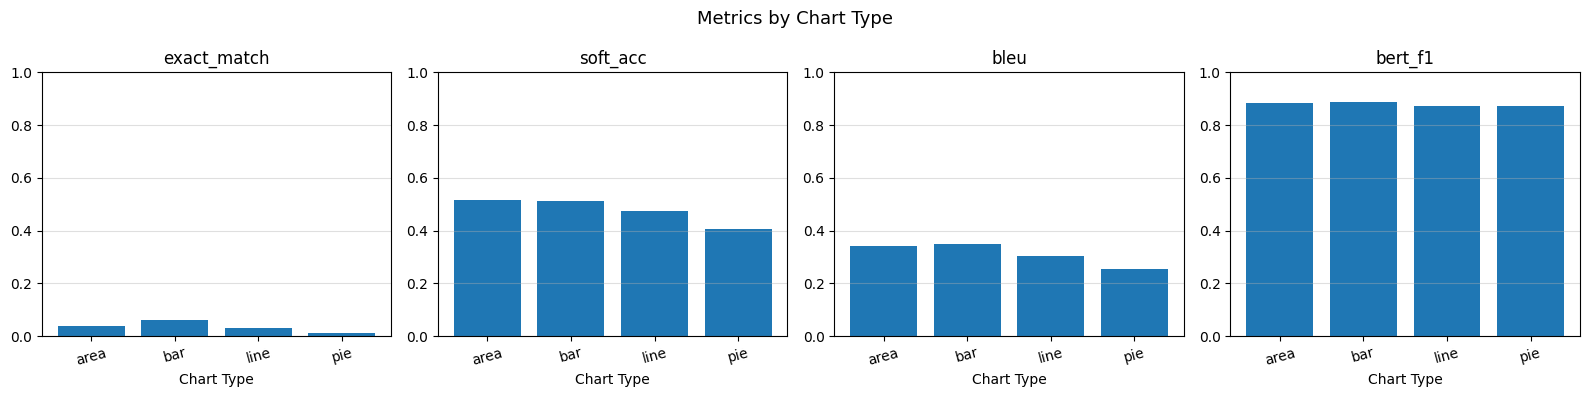

In [12]:
# ── Per chart-type breakdown ──────────────────────────────
chart_report = (
    df.groupby("chart_type")
    .agg(
        n          = ("exact_match", "count"),
        exact_match= ("exact_match", "mean"),
        soft_acc   = ("soft_acc",    "mean"),
        bleu       = ("bleu",        "mean"),
        rouge_l    = ("bert_f1",     "mean"),   # placeholder, rouge_l is global
        bert_f1    = ("bert_f1",     "mean"),
    )
    .round(4)
    .reset_index()
)

display(chart_report)
chart_report.to_csv(os.path.join(RESULT_DIR, "metrics_by_chart_type.csv"), index=False, encoding="utf-8-sig")

# Plot
metric_cols = ["exact_match", "soft_acc", "bleu", "bert_f1"]
fig, axes = plt.subplots(1, len(metric_cols), figsize=(16, 4))
for ax, col in zip(axes, metric_cols):
    ax.bar(chart_report["chart_type"], chart_report[col])
    ax.set_title(col)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Chart Type")
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.4)
plt.suptitle("Metrics by Chart Type", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "metrics_by_chart_type.png"), dpi=150)
plt.show()

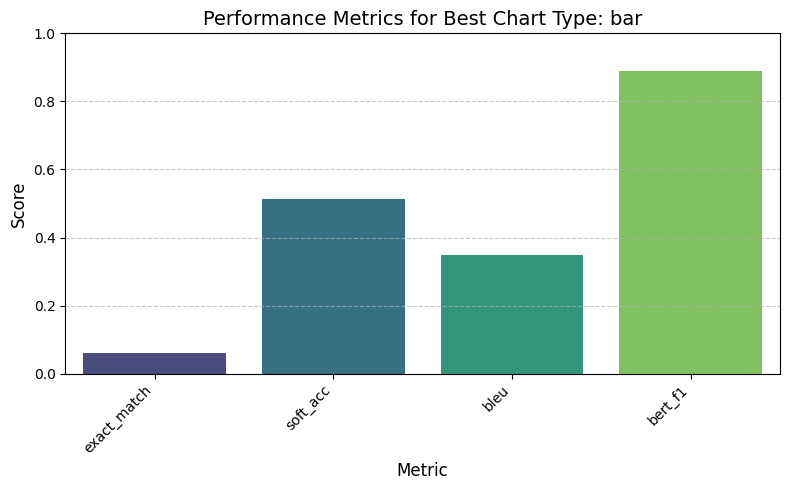

In [17]:
import seaborn as sns

best_chart_type_row = chart_report.loc[chart_report['bert_f1'].idxmax()]
best_chart_type_name = best_chart_type_row['chart_type']

# Prepare data for plotting the best chart type
metrics_for_plot = best_chart_type_row[metric_cols]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics_for_plot.index, y=metrics_for_plot.values, hue=metrics_for_plot.index, palette='viridis', legend=False)
plt.title(f'Performance Metrics for Best Chart Type: {best_chart_type_name}', fontsize=14)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Lưu kết quả tổng hợp

In [14]:
import datetime
summary = {
    "run_time"        : datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model"           : MODEL_ID,
    "dataset"         : DATASET_ID,
    "train_samples"   : len(train_ds),
    "val_samples"     : len(val_ds),
    "test_samples"    : len(test_ds),
    "lora_r"          : 16,
    "lora_alpha"      : 32,
    "epochs"          : training_args.num_train_epochs,
    "lr"              : training_args.learning_rate,
    "effective_batch" : training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps,
    "best_eval_loss"  : trainer.state.best_metric,
    **{f"test_{k}": v for k, v in metrics.items()},
}

summary_path = os.path.join(RESULT_DIR, "summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=4)

print(json.dumps(summary, ensure_ascii=False, indent=4))
print("Saved:", summary_path)

{
    "run_time": "2026-05-03 11:17:44",
    "model": "Qwen/Qwen2-VL-2B-Instruct",
    "dataset": "Zenng2812/vqa-vietnamese-charts",
    "train_samples": 3344,
    "val_samples": 416,
    "test_samples": 424,
    "lora_r": 16,
    "lora_alpha": 32,
    "epochs": 2,
    "lr": 1e-05,
    "effective_batch": 8,
    "best_eval_loss": 0.9928635954856873,
    "test_exact_match": 0.0401,
    "test_soft_acc": 0.4848,
    "test_bleu": 0.3201,
    "test_rouge_l": 0.4942,
    "test_bert_p": 0.8788,
    "test_bert_r": 0.8843,
    "test_bert_f1": 0.8811,
    "test_num_samples": 424
}
Saved: /content/drive/MyDrive/B2_Qwen2VL_VQA_Charts/results/summary.json
